In [1]:
import tensorflow as tf

## Load dataset

In [4]:
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 25s 2us/step


Enter a number: 222


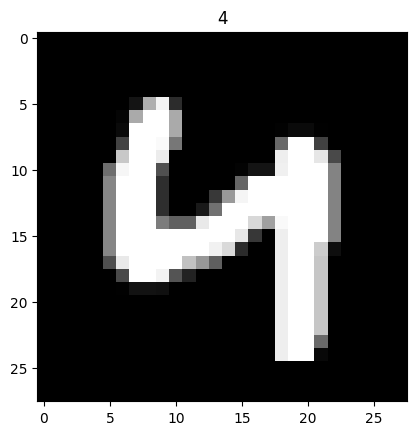

In [10]:
import matplotlib.pyplot as plt
i = int(input("Enter a number:"))
plt.imshow(X_train[i], cmap='gray')
plt.title(y_train[i]);

In [11]:
X_train.shape

(60000, 28, 28)

In [12]:
X_test.shape

(10000, 28, 28)

In [13]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10)
])

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
             metrics=['accuracy'])

In [15]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9136 - loss: 0.2979
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9585 - loss: 0.1420
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9672 - loss: 0.1069
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9732 - loss: 0.0869
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9768 - loss: 0.0753


In [16]:
model.evaluate(X_test, y_test, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.9780 - loss: 0.0740


[0.07397054135799408, 0.9779999852180481]

In [18]:
y_test[12]

np.uint8(9)

In [20]:
X_test[10].shape

(28, 28)

In [21]:
test_sample = X_test[12].reshape(1, 28, 28)

In [22]:
model.predict(test_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


array([[-11.051558  , -10.123937  ,  -8.245102  ,  -0.50707024,
          2.0271726 ,  -3.3361049 , -17.163467  ,   0.9655237 ,
         -3.304563  ,   9.905209  ]], dtype=float32)

In [23]:
probability_model = tf.keras.Sequential([
    model, tf.keras.layers.Softmax()
])

In [25]:
probability_model.predict(test_sample).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


np.int64(9)

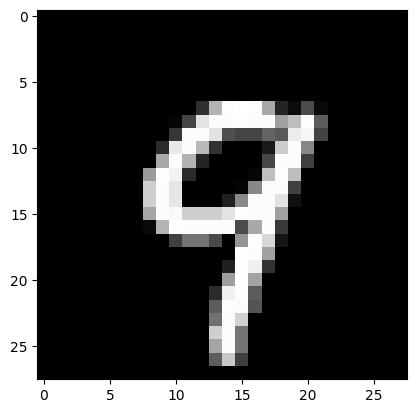

In [27]:
plt.imshow(test_sample[0], cmap='gray');